
**PROJECT SUMMARY **

**TITLE**: ENHANCING DRUG DEMAND FORECASTING AND INVENTORY MANAGEMENT USING MACHINE LEARNING

**AIM**: To outline the problem of drug stockouts and expiry waste in pharmacy operations, citing the financial and patient-care implications.

**PROBLEM STATEMENT** : Pharmacies face two competing inventory risks: overstocking (leading to drug expiry and financial loss) and understocking (leading to stockouts and unmet demand).

**OBJECTIVES**
Identify the most demanded drug

*  Identify the most demanded drug categories and forecast future demand.
*  Flag drugs at risk of expiry before they can be sold.
*  Predict stockout risk and recommend reorder points.
*  Build an actionable dashboard for pharmacy managers.


**DATASET DESCRIPTION:**
700 pharmacy transaction records covering 8 variables: Transaction_Date, Drug_Name, Category (11 classes), Quantity_Sold, Stock_On_Hand, Expiry_Date, Unit_Cost, and Supplier (6 suppliers). No missing values. This dataset was gotten from a hospital Medical records.

**METHODOLOGY DATA CLEANING** → Feature engineering → Exploratory Data Analysis → Classification model for expiry/stockout risk → Regression model for demand forecasting → Model evaluation → Dashboard and recommendations.

**TOOLS** Jupyter Notebook (pandas, numpy, matplotlib, ploty , scikit-learn, ), Power BI

[LINK TO DATASET](https://drive.google.com/file/d/1GDEO_XwUgPdGTJcJdu2iDpv64d6iv3Jh/view?usp=sharing)


In [4]:
# import the essential Python libraries for data manipulation,
#numerical operations, and plotting.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
#load the dataset into a pandas DataFrame named df and then view the first 5
df = pd.read_csv('Pharmacy_Store_Data.csv')
df.head()

,Transaction_Date,Drug_Name,Category,Quantity_Sold,Stock_On_Hand,Expiry_Date,Unit_Cost,Supplier
0,2024-04-23,Susp Hydralazine 5ml/125mg,Anti-Hypertensive,14,134,2027-01-23,835,Emzor
1,2023-06-28,Inf Glibenclamide 5ml/250mg,Anti-Diabetic,28,157,2027-10-27,251,MegaCare
2,2025-09-30,Syrup Pentazocine 5ml/250mg,Analgesics,15,127,2028-02-29,827,MegaCare
3,2025-07-02,Cap Paracetamol 1g,Analgesics,32,151,2028-06-09,929,Emzor
4,2025-08-21,Cap Oxytocin 500mg,Specialty/Emergency,45,149,2026-12-19,218,MegaCare


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_Date  700 non-null    object
 1   Drug_Name         700 non-null    object
 2   Category          700 non-null    object
 3   Quantity_Sold     700 non-null    int64 
 4   Stock_On_Hand     700 non-null    int64 
 5   Expiry_Date       700 non-null    object
 6   Unit_Cost         700 non-null    int64 
 7   Supplier          700 non-null    object
dtypes: int64(3), object(5)
memory usage: 43.9+ KB


In [7]:
#converting the dates to datetime data type inorder to perform date based operations
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
df['Expiry_Date'] = pd.to_datetime(df['Expiry_Date'])

**FEATURE ENGINEERING**
This involves creating new features or transforming existing ones from the raw data to improve the performance of machine learning models. We will be creating new columns like Stock_Status, Avg_daily_sales, Days_to_Stockout, Stockout_Date, stockout_priority, Days_To_Expiry, Expiry_Risk, year, month_name, and month_index from the original raw data.

In [8]:
#Categorizing stock on hand quantity inoder to create new column called stock status
def stock_status(x):
    if x < 50:
        return "Low"
    elif x < 100:
        return "Medium"
    else:
        return "High"

df['Stock_Status'] = df['Stock_On_Hand'].apply(stock_status)

In [9]:
df.head()

,Transaction_Date,Drug_Name,Category,Quantity_Sold,Stock_On_Hand,Expiry_Date,Unit_Cost,Supplier,Stock_Status
0,2024-04-23,Susp Hydralazine 5ml/125mg,Anti-Hypertensive,14,134,2027-01-23,835,Emzor,High
1,2023-06-28,Inf Glibenclamide 5ml/250mg,Anti-Diabetic,28,157,2027-10-27,251,MegaCare,High
2,2025-09-30,Syrup Pentazocine 5ml/250mg,Analgesics,15,127,2028-02-29,827,MegaCare,High
3,2025-07-02,Cap Paracetamol 1g,Analgesics,32,151,2028-06-09,929,Emzor,High
4,2025-08-21,Cap Oxytocin 500mg,Specialty/Emergency,45,149,2026-12-19,218,MegaCare,High


In [10]:
# Calculating the Average daily sales per drug
Avg_sales = df.groupby('Drug_Name')['Quantity_Sold'].transform('mean')
df['Avg_daily_sales'] = Avg_sales

In [11]:
#Days left for drugs to stock out
df['Days_to_Stockout'] = (df['Stock_On_Hand'] / df['Avg_daily_sales']).astype(int)
df['Stockout_Date'] = (pd.Timestamp.today() + pd.to_timedelta(df['Days_to_Stockout'], unit='D')).dt.normalize()

In [12]:
#displaying some columns
print(df[['Drug_Name', 'Stock_On_Hand', 'Days_to_Stockout', 'Stockout_Date']].head(10))

                     Drug_Name  Stock_On_Hand  Days_to_Stockout Stockout_Date
0   Susp Hydralazine 5ml/125mg            134                 9    2026-05-03
1  Inf Glibenclamide 5ml/250mg            157                 5    2026-04-29
2  Syrup Pentazocine 5ml/250mg            127                 8    2026-05-02
3           Cap Paracetamol 1g            151                 4    2026-04-28
4           Cap Oxytocin 500mg            149                 3    2026-04-27
5      Inj Normal Saline 500mg            112                12    2026-05-06
6   Ear Drops Esomeprazole 5mg            140                 2    2026-04-26
7               HIV Kit (10ml)            148                49    2026-06-12
8        Inf Amoxicillin 500mg            172                 3    2026-04-27
9      Gutt Chloramphenicol 1g            155                 4    2026-04-28


In [13]:
#assigning stockout risk status
conditions = [
    (df['Days_to_Stockout'] < 3),
    (df['Days_to_Stockout'] >= 3) & (df['Days_to_Stockout'] <= 10),
    (df['Days_to_Stockout'] > 10)
]
choices = ['High Risk', 'Medium Risk', 'Low Risk']

df['stockout_priority'] = np.select(conditions, choices, default='Stable')

In [14]:
#calculating the number of days remaining until each drug's expiry date from current day
df['Days_To_Expiry'] = (df['Expiry_Date'] - pd.Timestamp.today()).dt.days

In [15]:
#assigning expiry risk status
df['Expiry_Risk'] = df['Days_To_Expiry'] < df['Days_to_Stockout']

In [16]:
# View the clean labels
print(df[['Drug_Name', 'Days_To_Expiry','Expiry_Risk','Days_to_Stockout','stockout_priority']].head(10))

                     Drug_Name  Days_To_Expiry  Expiry_Risk  Days_to_Stockout  \
0   Susp Hydralazine 5ml/125mg             273        False                 9   
1  Inf Glibenclamide 5ml/250mg             550        False                 5   
2  Syrup Pentazocine 5ml/250mg             675        False                 8   
3           Cap Paracetamol 1g             776        False                 4   
4           Cap Oxytocin 500mg             238        False                 3   
5      Inj Normal Saline 500mg             663        False                12   
6   Ear Drops Esomeprazole 5mg             457        False                 2   
7               HIV Kit (10ml)             847        False                49   
8        Inf Amoxicillin 500mg             359        False                 3   
9      Gutt Chloramphenicol 1g             519        False                 4   

  stockout_priority  
0       Medium Risk  
1       Medium Risk  
2       Medium Risk  
3       Medium Risk 

In [17]:
# Extracting the  Year for demand forecasting
df['year'] = df['Transaction_Date'].dt.year

#  Month Name
df['month_name'] = df['Transaction_Date'].dt.month_name()

#  Month Number
df['month_index'] = df['Transaction_Date'].dt.month

In [18]:
print(df[['Transaction_Date', 'year', 'month_name', 'month_index']].head())

  Transaction_Date  year month_name  month_index
0       2024-04-23  2024      April            4
1       2023-06-28  2023       June            6
2       2025-09-30  2025  September            9
3       2025-07-02  2025       July            7
4       2025-08-21  2025     August            8


**EXPLORATORY DATA ANALYSIS** to discover patterns and trends

Visualizing Total Demand by Category
and
Sales Trend Over Time


In [19]:
import plotly.express as px

demand_by_category_data = df.groupby('Category')['Quantity_Sold'].sum().sort_values().reset_index()

# interactive bar chart with Plotly Express
fig_plotly = px.bar(
    demand_by_category_data,
    x='Quantity_Sold',
    y='Category',
    orientation='h',
    title='<b>Total Demand by Category</b>',
    labels={'Quantity_Sold': 'Quantity Sold', 'Category': 'Category'}
)
fig_plotly.update_layout(
    xaxis_title=dict(text='<b>Quantity Sold</b>', font=dict(size=14)),
    yaxis_title=dict(text='<b>Category</b>', font=dict(size=14))
)
fig_plotly.update_traces(hovertemplate='<b>%{x}</b>')

fig_plotly.show()

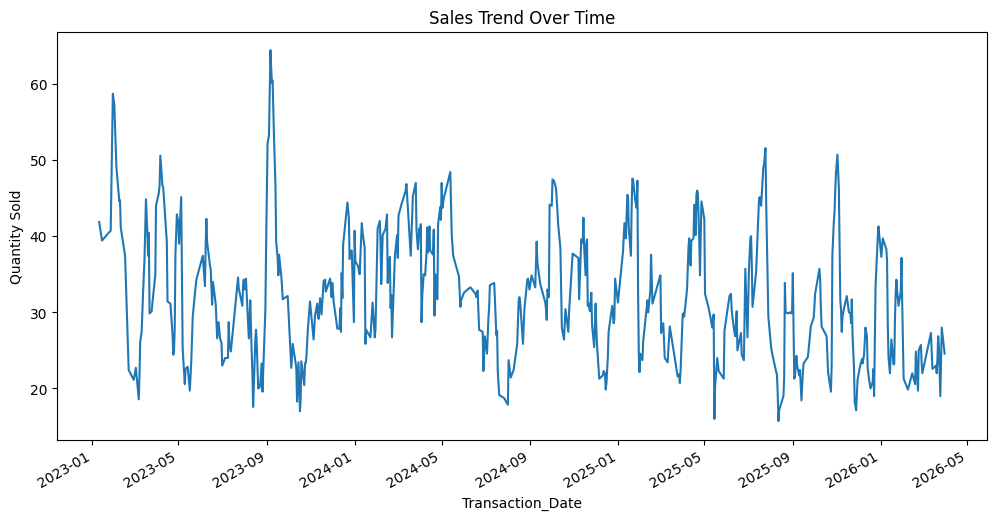

In [20]:
# Sales Trend (7-day rolling average)
plt.figure(figsize=(12, 6))
df.groupby('Transaction_Date')['Quantity_Sold'].sum().rolling(window=7).mean().plot()
plt.title('Sales Trend Over Time')
plt.ylabel('Quantity Sold')
plt.savefig('sales_trend.png')

In [21]:
# Potential Financial Loss: sum of value of stock about to expire
expiring_stock = df[df['Expiry_Risk'] == True]
total_loss_value = (expiring_stock['Stock_On_Hand'] * expiring_stock['Unit_Cost']).sum()
print(f"Potential Financial Loss from Expiry: ₦{total_loss_value:,.2f}")

Potential Financial Loss from Expiry: ₦2,894,253.00


**DEMAND FORECASTING MODEL**
The demand forecasting model utilizes a RandomForestRegressor to predict drug Quantity_Sold. It leverages encoded features like Drug_Name, Category, Supplier, Stock_On_Hand, and time components. Data is split into training/testing sets, the model is trained, and predictions are evaluated using MAE and RMSE to assess accuracy. The goal is to forecast future drug demand effectively.

In [22]:
#importing libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700 entries, 0 to 699
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Transaction_Date   700 non-null    datetime64[ns]
 1   Drug_Name          700 non-null    object        
 2   Category           700 non-null    object        
 3   Quantity_Sold      700 non-null    int64         
 4   Stock_On_Hand      700 non-null    int64         
 5   Expiry_Date        700 non-null    datetime64[ns]
 6   Unit_Cost          700 non-null    int64         
 7   Supplier           700 non-null    object        
 8   Stock_Status       700 non-null    object        
 9   Avg_daily_sales    700 non-null    float64       
 10  Days_to_Stockout   700 non-null    int64         
 11  Stockout_Date      700 non-null    datetime64[ns]
 12  stockout_priority  700 non-null    object        
 13  Days_To_Expiry     700 non-null    int64         
 14  Expiry_Ris

In [24]:
# Encode categorical variables
le_drug = LabelEncoder()
le_cat = LabelEncoder()
le_sup = LabelEncoder()

In [25]:
# Apply Label Encoding to each categorical column
df['Drug_Name'] = le_drug.fit_transform(df['Drug_Name'])
df['Category'] = le_cat.fit_transform(df['Category'])
df['Supplier'] = le_sup.fit_transform(df['Supplier'])

In [26]:
# Creating Features(X) & target(Y).Features is the variables we are training
# with while target(Y) is what we are predicting
X = df[['Drug_Name','Category','Supplier',
        'Stock_On_Hand','Days_To_Expiry','Unit_Cost','month_index','year']]
y = df['Quantity_Sold']

In [27]:
# To view all the columns and variables contained in X
X

,Drug_Name,Category,Supplier,Stock_On_Hand,Days_To_Expiry,Unit_Cost,month_index,year
0,539,2,0,134,273,835,4,2024
1,275,1,4,157,550,251,6,2023
2,632,0,4,127,675,827,9,2025
3,50,0,0,151,776,929,7,2025
4,48,9,4,149,238,218,8,2025
...,...,...,...,...,...,...,...,...
695,623,5,2,108,689,532,3,2023
696,455,6,2,179,801,325,7,2025
697,4,9,4,156,662,816,11,2024
698,395,1,5,143,12,531,12,2024


In [28]:
# To view all the columns and variables contained in Y
y

,Quantity_Sold
0,14
1,28
2,15
3,32
4,45
...,...
695,48
696,19
697,18
698,11


In [29]:
# Split our data into 80% training data and 20% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [30]:
print(X_train.shape)
print(y_train.shape)

(560, 8)
(560,)


In [31]:
print(X_test.shape)
print(y_test.shape)

(140, 8)
(140,)


In [32]:
# Initializing and training the Random Forest Regressor model for
#demand forecasting
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [33]:
# Performing predictions using the trained RandomForestRegressor model.
y_pred = model.predict(X_test)
y_pred

array([20.44, 25.55, 26.09, 26.83, 30.37, 27.32, 27.33, 24.07, 32.05,
       26.6 , 19.81, 29.23, 25.5 , 14.95, 19.06, 23.8 , 18.33, 19.9 ,
       27.19, 23.98, 28.93, 21.46, 22.18, 23.15, 25.57, 28.73, 27.86,
       21.17, 21.02, 25.2 , 17.12, 21.24, 30.77, 28.06, 22.14, 16.55,
       21.79, 15.97, 23.34, 21.8 , 20.12, 27.37, 24.22, 18.52, 19.25,
       28.67, 17.72, 22.99, 27.65, 20.53, 21.53, 19.53, 25.69, 31.86,
       24.9 , 24.52, 25.85, 13.33, 28.  , 21.46, 28.88, 24.17, 24.16,
       24.43, 21.38, 27.22, 22.61, 19.64, 34.95, 24.38, 19.76, 29.64,
       23.97, 20.91, 25.07, 26.23, 24.68, 25.13, 23.49, 24.41, 29.82,
       30.76, 20.83, 30.37, 23.78, 29.55, 21.3 , 24.41, 28.01, 35.04,
       25.17, 29.66, 28.79, 17.3 , 23.86, 25.06, 20.88, 28.23, 26.55,
       24.95, 27.8 , 25.79, 26.17, 28.34, 15.73, 32.08, 21.68, 23.52,
       26.28, 23.27, 26.27, 27.97, 22.1 , 24.96, 23.42, 21.42, 34.14,
       32.52, 30.31, 27.23, 21.12, 27.64, 19.53, 24.93, 28.91, 22.1 ,
       17.65, 30.54,

In [34]:
# Evaluation to measure the average gap between the model's
# predicted drug sales and the actual sales recorded in the data.
MAE = mean_absolute_error(y_test, y_pred)
RMSE = np.sqrt(mean_squared_error(y_test, y_pred))

In [35]:
print("MAE:", MAE)
print("RMSE:", RMSE)

MAE: 13.096642857142857
RMSE: 15.381259492363705


###**EXPLANATION OF THE RESULT**
 The Random Forest model achieved a Mean Absolute Error (MAE) of 13.1 and a Root Mean Square Error (RMSE) of 15.4, indicating a moderate level of prediction accuracy.  The model's average deviation suggests some level of forecasting uncertainty. However, the predictions are sufficiently reliable to support inventory planning when combined with safety buffers. This allows pharmacy managers to make informed restocking decisions while accounting for potential variation in demand.

In [39]:
#Adding the predicted value to our data
df['Predicted_Demand'] = model.predict(X)

###** Classification Model for Stockout Risk**
To predict which medications are likely to run out of stock before they can be replenished Using RandomForestClassifier

In [40]:
#Importing the required library
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

In [41]:
# Re-initialize LabelEncoder for the target variable
le_stockout_priority = LabelEncoder()

In [42]:
# Encode the target variable 'stockout_priority'
df['stockout_priority'] = le_stockout_priority.fit_transform(df['stockout_priority'])


In [43]:
# Define features (X_clf) and target (y_clf) for the classification model
X_clm = df[['Drug_Name', 'Category', 'Supplier', 'Stock_On_Hand', 'Days_To_Expiry', 'Unit_Cost', 'month_index', 'year', 'Avg_daily_sales']]
y_clm = df['stockout_priority']

In [44]:
# Split the data into training and testing sets
X_train_clm, X_test_clm, y_train_clm, y_test_clm = train_test_split(X_clm, y_clm, test_size=0.2, random_state=42)

In [45]:
# Initialize and train the RandomForestClassifier
classifier_model = RandomForestClassifier(n_estimators=100, random_state=42)
classifier_model.fit(X_train_clm, y_train_clm)

RandomForestClassifier(random_state=42)

In [46]:
# Make predictions on the test set
y_pred_clm = classifier_model.predict(X_test_clm)

In [47]:
#Evaluate the stockout risk classification model
print(f"Accuracy: {accuracy_score(y_test_clm, y_pred_clm):.2f}")
print(f"Precision: {precision_score(y_test_clm, y_pred_clm, average='weighted'):.2f}")
print(f"Recall: {recall_score(y_test_clm, y_pred_clm, average='weighted'):.2f}")

Accuracy: 0.91
Precision: 0.91
Recall: 0.91


**EXPLANATION OF THE RESULT**
Our stockout risk classification model achieved Accuracy, Precision, and Recall all at 91% (0.91). This indicate that the model is highly effective at identifying drugs at risk of stockout.

For Accuracy: 91% of all predictions (whether a drug would stock out or not) were correct.

Precision: When the model predicts a stockout, it is correct 91% of the time, minimizing false alarms.

Recall: The model successfully identifies 91% of all actual stockout events, meaning it's good at catching most of the drugs that will truly run out.

### Classification Model for Expiry Risk
Using Random ForestClassifier.
we dont need to encode Expiry risk because it is in boolean format(True/False). Classification models, particularly RandomForestClassifier, can directly handle boolean values as target variables without needing them to be explicitly encoded into numerical labels using a LabelEncoder.

In [48]:
# Define features (X_exp) and target (y_exp) for the expiry risk classification model
X_exp = df[['Drug_Name', 'Category', 'Supplier', 'Stock_On_Hand', 'Days_To_Expiry', 'Unit_Cost', 'month_index', 'year', 'Avg_daily_sales']]
y_exp = df['Expiry_Risk']

In [49]:
# Split the data into training and testing sets
X_train_exp, X_test_exp, y_train_exp, y_test_exp = train_test_split(X_exp, y_exp, test_size=0.2, random_state=42)

In [50]:
# Initialize and train the RandomForestClassifier for expiry risk
expiry_classifier_model = RandomForestClassifier(n_estimators=100, random_state=42)
expiry_classifier_model.fit(X_train_exp, y_train_exp)

RandomForestClassifier(random_state=42)

In [51]:
# Make predictions on the test set for expiry risk
y_pred_exp = expiry_classifier_model.predict(X_test_exp)

In [52]:
# Evaluate the expiry risk classification model
print(f"Expiry Risk Accuracy: {accuracy_score(y_test_exp, y_pred_exp):.2f}")
print(f"Expiry Risk Precision: {precision_score(y_test_exp, y_pred_exp, average='weighted'):.2f}")
print(f"Expiry Risk Recall: {recall_score(y_test_exp, y_pred_exp, average='weighted'):.2f}")

Expiry Risk Accuracy: 0.99
Expiry Risk Precision: 0.99
Expiry Risk Recall: 0.99


**EXPLANATION OF THE RESULT **
Our expiry risk classification model indicated that the Accuracy, Precision, and Recall all at 99% (0.99). This indicates that the model is highly reliable in identifying drugs that are at risk of expiring.

Accuracy: 99% of all its predictions regarding expiry risk (whether a drug was or wasn't at risk) were correct.

Precision: When the model predicts that a drug is at expiry risk, it is correct 99% of the time.

Recall: The model successfully identifies 99% of all drugs that are actually at expiry risk. This shows its excellent ability to catch nearly all the true expiry cases, minimizing the chances of missing drugs that are about to expire.

In [57]:
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

# Create a copy of the DataFrame to ensure all original columns are present for inverse transformation
export_df = df.copy()

# Inverse transform the label-encoded columns to get original string values
# Overwrite the encoded columns with their string representations
export_df['Drug_Name'] = le_drug.inverse_transform(export_df['Drug_Name'])
export_df['Category'] = le_cat.inverse_transform(export_df['Category'])
export_df['Supplier'] = le_sup.inverse_transform(export_df['Supplier'])

# Inverse transform stockout_priority
# Ensure these column is of integer type before inverse_transform
export_df['stockout_priority'] = export_df['stockout_priority'].astype(int)

# Create new columns for the inverse-transformed stockout priorities
export_df['Original_Stockout_Priority'] = le_stockout_priority.inverse_transform(export_df['stockout_priority'])

# Drop the numerical encoded columns that are now duplicated by the new string columns,
# and any other columns that are not needed for the final export (like Stock_Status if not needed).
columns_to_drop = [
    'stockout_priority',
    'predicted_stockout_risk',
]
export_df = export_df.drop(columns=columns_to_drop, errors='ignore')

# Reorder columns to place new string names in a logical order
current_cols = export_df.columns.tolist()

ordered_cols = [
    'Transaction_Date', 'Drug_Name', 'Category', 'Quantity_Sold', 'Stock_On_Hand',
    'Stock_Status','Expiry_Date', 'Unit_Cost', 'Supplier', 'Avg_daily_sales', 'Days_to_Stockout',
    'Stockout_Date', 'Original_Stockout_Priority', 'Days_To_Expiry', 'Expiry_Risk',
    'year', 'month_name', 'month_index', 'Predicted_Demand'
]

# Filter ordered_cols to only include columns actually present in export_df
final_ordered_cols = [col for col in ordered_cols if col in current_cols]


export_df = export_df[final_ordered_cols]

In [58]:
# Save the DataFrame to a CSV file
output_filename = 'pharmacy_store_data_for_powerbi.csv'
export_df.to_csv(output_filename, index=False)

In [59]:
from google.colab import files

files.download('pharmacy_store_data_for_powerbi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

[POWERBI DASHBOARD VISUALIZATION](https://app.powerbi.com/view?r=eyJrIjoiOWQ0MWYxMWUtNjZmYS00Yzc2LTlhOGEtYWU1NmIyZTNiOTE1IiwidCI6IjFhMzkzODdkLWM4ZDItNGI2YS1iNmYzLWJkZjkyMWU3MjE4ZCJ9&pageName=cae2cfd810a26dc5e48b)